# Ridge And Lasso Logistic Regression

This notebook trains and compares ridge logistic regression and lasso logistic regression on the Tommy Award same-game dataset.

It uses the top same-game feature set from `Same_Game_And_Pregame_Logistic_Experiments.ipynb` so the notebook matches the feature style you have already been using.

In [4]:
# Import the libraries used for loading data, preprocessing,
# model training, evaluation, and coefficient inspection.
import random
import warnings
import numpy as np
import optuna
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*penalty=l1.*", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Basic configuration shared across the notebook.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
INPUT_PATH = "Tommy_Award_Player_Game_Table_hustle.csv"
RANDOM_STATE = SEED
MIN_TRAIN_SEASONS = 3
TEST_SEASONS = ["2024-25", "2025-26"]
PRED_THRESHOLD = 0.5
ELASTICNET_L1_RATIO = 0.5
OPTUNA_TRIALS = 40
OPTUNA_C_LOW = 1e-3
OPTUNA_C_HIGH = 1e2

In [5]:
# Load the dataset, recreate any missing derived same-game features,
# and define the shared feature list from Same_Game_And_Pregame_Logistic_Experiments.ipynb.
def load_dataset(path: str = INPUT_PATH) -> pd.DataFrame:
    df = pd.read_csv(path, dtype={"GAME_ID": str}).copy()
    df["game_date"] = pd.to_datetime(df["game_date"], format="mixed")

    # Keep only players who actually played in the game.
    df = df[df["minutes_decimal"] > 0].copy()

    mins = df["minutes_decimal"].clip(lower=1e-6)
    if "stocks" not in df.columns:
        df["stocks"] = df["steals"] + df["blocks"]
    if "points_per_min" not in df.columns:
        df["points_per_min"] = df["points"] / mins
    if "oreb_per_min" not in df.columns:
        df["oreb_per_min"] = df["reboundsOffensive"] / mins
    if "reb_per_min" not in df.columns:
        df["reb_per_min"] = df["reboundsTotal"] / mins
    if "ast_per_min" not in df.columns:
        df["ast_per_min"] = df["assists"] / mins
    if "deflections" not in df.columns:
        if "DEFLECTIONS" in df.columns:
            df["deflections"] = df["DEFLECTIONS"]
        else:
            df["deflections"] = 0.0

    if "charges_drawn" not in df.columns:
        if "chargesDrawn" in df.columns:
            df["charges_drawn"] = df["chargesDrawn"]
        elif "CHARGES_DRAWN" in df.columns:
            df["charges_drawn"] = df["CHARGES_DRAWN"]
        else:
            df["charges_drawn"] = 0.0

    # Define hustle proxy as per-minute hustle actions.
    df["hustle_proxy"] = (df["reboundsOffensive"] + df["steals"] + df["blocks"]) / mins
    if "stocks_per_min" not in df.columns:
        df["stocks_per_min"] = df["stocks"] / mins

    # Build net_rating and usage_rate with fallbacks when raw fields are missing.
    if "net_rating" in df.columns:
        df["net_rating"] = pd.to_numeric(df["net_rating"], errors="coerce")
    elif "Net_Rating" in df.columns:
        df["net_rating"] = pd.to_numeric(df["Net_Rating"], errors="coerce")
    elif "NET_RATING" in df.columns:
        df["net_rating"] = pd.to_numeric(df["NET_RATING"], errors="coerce")
    else:
        # Fallback proxy when no explicit net rating is available.
        df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

    if "usage_rate" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["usage_rate"], errors="coerce")
    elif "Usage_Rate" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["Usage_Rate"], errors="coerce")
    elif "USG_PCT" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["USG_PCT"], errors="coerce") / 100.0
    else:
        # Proxy usage share within each game if explicit usage rate is absent.
        usage_numerator = (
            pd.to_numeric(df["fieldGoalsAttempted"], errors="coerce").fillna(0)
            + 0.44 * pd.to_numeric(df["freeThrowsAttempted"], errors="coerce").fillna(0)
            + pd.to_numeric(df["turnovers"], errors="coerce").fillna(0)
        )
        usage_denom = usage_numerator.groupby(df["GAME_ID"]).transform("sum")
        df["usage_rate"] = (usage_numerator / usage_denom.replace(0, np.nan)).fillna(0.0)

    df["usage_rate"] = df["usage_rate"].clip(lower=0, upper=1)
    eps = 1e-6
    df["impact_efficiency"] = df["net_rating"] / (df["usage_rate"] + eps)
    df["role_outperformance"] = df["net_rating"] * (1 - df["usage_rate"])

    rank_sources = {
        "points_rank": "points",
        "reboundsOffensive_rank": "reboundsOffensive",
        "reboundsTotal_rank": "reboundsTotal",
        "assists_rank": "assists",
        "steals_rank": "steals",
        "blocks_rank": "blocks",
        "plusMinusPoints_rank": "plusMinusPoints",
        "minutes_decimal_rank": "minutes_decimal",
        "stocks_rank": "stocks",
        "hustle_proxy_rank": "hustle_proxy",
    }
    for rank_col, source_col in rank_sources.items():
        if rank_col not in df.columns:
            df[rank_col] = df.groupby("GAME_ID")[source_col].rank(method="min", ascending=False)

    if "season" not in df.columns:
        start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
        df["season"] = start_year.astype(str) + "-" + (start_year + 1).astype(str).str[-2:]

    return df


def sorted_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda season: int(str(season).split("-")[0]))


def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    numeric_cols = [
        "minutes_decimal",
        "points",
        "reboundsOffensive",
        "reboundsDefensive",
        "reboundsTotal",
        "assists",
        "steals",
        "blocks",
        "deflections",
        "charges_drawn",
        "turnovers",
        "foulsPersonal",
        "plusMinusPoints",
        "net_rating",
        "usage_rate",
        "impact_efficiency",
        "role_outperformance",
        "fieldGoalsMade",
        "fieldGoalsAttempted",
        "threePointersMade",
        "threePointersAttempted",
        "freeThrowsMade",
        "stocks",
        "points_per_min",
        "oreb_per_min",
        "reb_per_min",
        "ast_per_min",
        "stocks_per_min",
        "hustle_proxy",
        "points_rank",
        "reboundsOffensive_rank",
        "reboundsTotal_rank",
        "assists_rank",
        "steals_rank",
        "blocks_rank",
        "plusMinusPoints_rank",
        "minutes_decimal_rank",
        "stocks_rank",
        "hustle_proxy_rank",
    ]

    missing_cols = [col for col in numeric_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing feature columns: {missing_cols}")

    return numeric_cols, []


def latest_season_holdout_split(
    df: pd.DataFrame,
    test_seasons: list[str] = TEST_SEASONS,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    seasons = sorted_seasons(df["season"].dropna().unique().tolist())
    selected_test_seasons = [season for season in test_seasons if season in seasons]
    if not selected_test_seasons:
        raise ValueError(
            f"None of the requested test seasons were found. Requested={test_seasons}, available={seasons}"
        )

    train_df = df[~df["season"].isin(selected_test_seasons)].copy()
    test_df = df[df["season"].isin(selected_test_seasons)].copy()
    return train_df, test_df, selected_test_seasons

In [6]:
# Build the numeric preprocessing and the two logistic regression models.
def build_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
        ]
    )


def build_ridge_pipeline(
    numeric_cols: list[str],
    categorical_cols: list[str],
    c_value: float = 1.0,
) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="l2",
                    C=c_value,
                    solver="lbfgs",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def build_lasso_pipeline(
    numeric_cols: list[str],
    categorical_cols: list[str],
    c_value: float = 1.0,
) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    C=c_value,
                    solver="liblinear",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def build_elasticnet_pipeline(
    numeric_cols: list[str],
    categorical_cols: list[str],
    c_value: float = 1.0,
) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="elasticnet",
                    l1_ratio=ELASTICNET_L1_RATIO,
                    C=c_value,
                    solver="saga",
                    max_iter=10000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def available_model_names() -> list[str]:
    return ["ridge_logistic", "lasso_logistic", "elasticnet_logistic"]

In [7]:
# Score predictions using the same game-level and row-level metrics
# used in your other modeling notebooks.
def score_predictions(scored_df: pd.DataFrame) -> dict[str, float]:
    y_true = scored_df["y"].astype(int)
    y_prob = scored_df["pred_prob"].clip(1e-6, 1 - 1e-6)

    # Rank-1 logic: exactly one predicted winner per game.
    winner_idx = scored_df.groupby("GAME_ID")["pred_prob"].idxmax()
    y_pred = pd.Series(0, index=scored_df.index, dtype=int)
    y_pred.loc[winner_idx] = 1

    return {
        "game_top1_accuracy": scored_df.loc[winner_idx, "y"].mean(),
        "row_f1": f1_score(y_true, y_pred, zero_division=0),
        "row_recall": recall_score(y_true, y_pred, zero_division=0),
        "row_prauc": average_precision_score(y_true, y_prob),
        "row_precision": precision_score(y_true, y_pred, zero_division=0),
    }


def build_model_pipeline(
    model_name: str,
    numeric_cols: list[str],
    categorical_cols: list[str],
    c_value: float,
) -> Pipeline:
    if model_name == "ridge_logistic":
        return build_ridge_pipeline(numeric_cols, categorical_cols, c_value=c_value)
    if model_name == "lasso_logistic":
        return build_lasso_pipeline(numeric_cols, categorical_cols, c_value=c_value)
    if model_name == "elasticnet_logistic":
        return build_elasticnet_pipeline(numeric_cols, categorical_cols, c_value=c_value)
    raise ValueError(f"Unsupported model_name: {model_name}")


def temporal_validation_split(train_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    seasons = sorted_seasons(train_df["season"].dropna().unique().tolist())
    if len(seasons) < 2:
        raise ValueError("Need at least 2 training seasons to run Optuna validation split.")

    val_season = seasons[-1]
    inner_train_df = train_df[train_df["season"].isin(seasons[:-1])].copy()
    val_df = train_df[train_df["season"] == val_season].copy()

    if inner_train_df.empty or val_df.empty:
        raise ValueError("Validation split produced empty train/validation frames.")

    return inner_train_df, val_df


def tune_best_c(
    model_name: str,
    train_df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    n_trials: int = OPTUNA_TRIALS,
) -> float:
    inner_train_df, val_df = temporal_validation_split(train_df)
    feature_cols = numeric_cols + categorical_cols

    X_inner_train = inner_train_df[feature_cols]
    y_inner_train = inner_train_df["y"]
    X_val = val_df[feature_cols]

    def objective(trial: optuna.trial.Trial) -> float:
        c_value = trial.suggest_float("C", OPTUNA_C_LOW, OPTUNA_C_HIGH, log=True)
        model = build_model_pipeline(model_name, numeric_cols, categorical_cols, c_value=c_value)
        model.fit(X_inner_train, y_inner_train)

        scored_df = val_df.copy()
        scored_df["pred_prob"] = model.predict_proba(X_val)[:, 1]
        metrics = score_predictions(scored_df)
        return metrics["game_top1_accuracy"]

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials)
    return float(study.best_params["C"])


def fit_and_score_model(
    model_name: str,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    c_value: float = 1.0,
) -> tuple[Pipeline, pd.DataFrame, dict[str, float]]:
    feature_cols = numeric_cols + categorical_cols
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df["y"]

    model = build_model_pipeline(
        model_name,
        numeric_cols,
        categorical_cols,
        c_value=c_value,
    )
    model.fit(X_train, y_train)

    scored_df = test_df.copy()
    scored_df["pred_prob"] = model.predict_proba(X_test)[:, 1]
    metrics = score_predictions(scored_df)
    return model, scored_df, metrics


def rank_results(results_df: pd.DataFrame) -> pd.DataFrame:
    ranked_df = results_df.sort_values(
        by=[
            "game_top1_accuracy",
            "row_f1",
            "row_recall",
            "row_prauc",
            "row_precision",
        ],
        ascending=[False, False, False, False, False],
    ).reset_index(drop=True)
    ranked_df.insert(0, "rank", range(1, len(ranked_df) + 1))
    return ranked_df

In [1]:
# Load the data, inspect the shared feature set, and summarize the modeling setup.
df = load_dataset()
numeric_cols, categorical_cols = get_feature_columns(df)
model_names = available_model_names()
train_df, latest_test_df, selected_test_seasons = latest_season_holdout_split(df)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_cols),
            len(categorical_cols),
            train_df["GAME_ID"].nunique(),
            latest_test_df["GAME_ID"].nunique(),
            round(train_df["y"].mean(), 4),
            ", ".join(selected_test_seasons),
            ", ".join(model_names),
        ],
    }
)

display(summary_df)

NameError: name 'load_dataset' is not defined

In [6]:
# Walk-forward evaluation removed.
# This notebook now uses a fixed season split:
# - train: all seasons except TEST_SEASONS
# - test: seasons in TEST_SEASONS
pass

In [7]:
# Tune C with Optuna per model, then train on non-test seasons and evaluate on selected test seasons.
latest_rows = []
trained_models = {}
latest_scored_outputs = {}
best_c_by_model = {}

test_season_label = ", ".join(selected_test_seasons)

for model_name in model_names:
    best_c = tune_best_c(
        model_name,
        train_df,
        numeric_cols,
        categorical_cols,
        n_trials=OPTUNA_TRIALS,
    )
    best_c_by_model[model_name] = best_c

    model, scored_df, metrics = fit_and_score_model(
        model_name,
        train_df,
        latest_test_df,
        numeric_cols,
        categorical_cols,
        c_value=best_c,
    )
    trained_models[model_name] = model
    latest_scored_outputs[model_name] = scored_df
    latest_rows.append(
        {
            "model": model_name,
            "best_c": best_c,
            "test_seasons": test_season_label,
            **metrics,
        }
    )

latest_results_df = pd.DataFrame(latest_rows)
latest_ranked_df = rank_results(latest_results_df)

display(latest_ranked_df.round(4))

,rank,model,best_c,test_seasons,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,1,ridge_logistic,0.0179,"2024-25, 2025-26",0.3926,0.3926,0.3926,0.3168,0.3926
1,2,elasticnet_logistic,0.0276,"2024-25, 2025-26",0.3804,0.3804,0.3804,0.3168,0.3804
2,3,lasso_logistic,0.0253,"2024-25, 2025-26",0.3497,0.3497,0.3497,0.3083,0.3497


In [8]:
# Inspect the largest coefficients from each trained model.
# Ridge keeps all coefficients, while lasso may push some exactly to zero.
coefficient_tables = {}

for model_name, pipeline in trained_models.items():
    log_model = pipeline.named_steps["clf"]
    coef_df = pd.DataFrame(
        {
            "feature": numeric_cols,
            "coefficient": log_model.coef_[0],
        }
    )
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
    coefficient_tables[model_name] = coef_df

    print(f"\nTop coefficients: {model_name}")
    display(coef_df.head(20).round(4))


Top coefficients: ridge_logistic


,feature,coefficient,abs_coefficient
29,points_rank,-0.9289,0.9289
18,fieldGoalsAttempted,-0.7537,0.7537
17,fieldGoalsMade,0.5120,0.5120
23,points_per_min,0.4104,0.4104
1,points,0.3559,0.3559
35,plusMinusPoints_rank,-0.3329,0.3329
2,reboundsOffensive,0.2785,0.2785
0,minutes_decimal,0.2394,0.2394
10,turnovers,-0.2029,0.2029
5,assists,0.1907,0.1907



Top coefficients: lasso_logistic


,feature,coefficient,abs_coefficient
29,points_rank,-1.0656,1.0656
17,fieldGoalsMade,0.8500,0.8500
18,fieldGoalsAttempted,-0.7555,0.7555
2,reboundsOffensive,0.2387,0.2387
22,stocks,0.2224,0.2224
35,plusMinusPoints_rank,-0.2217,0.2217
23,points_per_min,0.1818,0.1818
10,turnovers,-0.1532,0.1532
9,charges_drawn,0.1528,0.1528
19,threePointersMade,0.1395,0.1395



Top coefficients: elasticnet_logistic


,feature,coefficient,abs_coefficient
29,points_rank,-1.0684,1.0684
18,fieldGoalsAttempted,-0.8492,0.8492
17,fieldGoalsMade,0.6953,0.6953
23,points_per_min,0.3363,0.3363
35,plusMinusPoints_rank,-0.2784,0.2784
2,reboundsOffensive,0.2599,0.2599
22,stocks,0.2409,0.2409
10,turnovers,-0.1799,0.1799
1,points,0.1769,0.1769
9,charges_drawn,0.1699,0.1699


In [9]:
# Show the full shared feature set used by both models.
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print("Numeric features")
display(pd.DataFrame({"numeric_feature": numeric_cols}))

print("Categorical features")
display(pd.DataFrame({"categorical_feature": categorical_cols}))

Numeric features


,numeric_feature
0,minutes_decimal
1,points
2,reboundsOffensive
3,reboundsDefensive
4,reboundsTotal
5,assists
6,steals
7,blocks
8,deflections
9,charges_drawn


Categorical features


,categorical_feature


Model for confusion matrix: ridge_logistic
Evaluation split: 2024-25, 2025-26
Prediction rule: rank-1 winner per game (argmax pred_prob)
TP=64, FP=99, FN=99, TN=1477


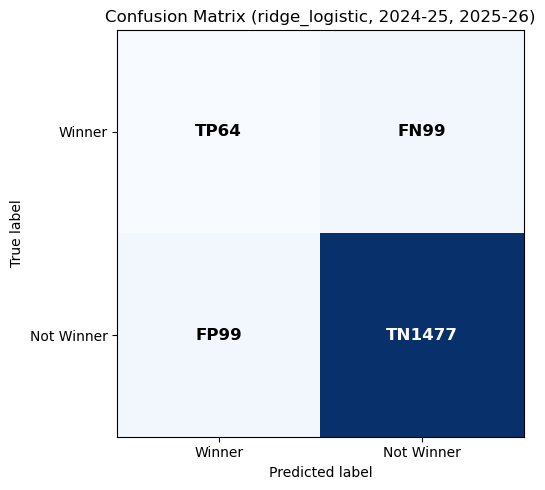

In [10]:
# Confusion matrix for the top-ranked model on the selected test seasons.
# Uses class order [Winner=1, Not Winner=0] so layout is:
# [[TP, FN],
#  [FP, TN]]
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

if "latest_ranked_df" not in globals() or "latest_scored_outputs" not in globals():
    raise RuntimeError("Run the model training/evaluation cells first.")

best_model_name = latest_ranked_df.iloc[0]["model"]
cm_df = latest_scored_outputs[best_model_name].copy()

y_true = cm_df["y"].astype(int)
y_prob = cm_df["pred_prob"].clip(1e-6, 1 - 1e-6)

# Rank-1 logic: one predicted winner per GAME_ID.
winner_idx = cm_df.groupby("GAME_ID")["pred_prob"].idxmax()
y_pred = pd.Series(0, index=cm_df.index, dtype=int)
y_pred.loc[winner_idx] = 1

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
tp, fn, fp, tn = cm.ravel()

test_season_label = ", ".join(selected_test_seasons) if "selected_test_seasons" in globals() else "selected test seasons"
print(f"Model for confusion matrix: {best_model_name}")
print(f"Evaluation split: {test_season_label}")
print("Prediction rule: rank-1 winner per game (argmax pred_prob)")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Winner", "Not Winner"]).plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    colorbar=False,
)

cell_labels = [["TP", "FN"], ["FP", "TN"]]
threshold = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        label = cell_labels[i][j]
        color = "white" if value > threshold else "black"
        ax.text(
            j,
            i,
            f"{label}{value}",
            ha="center",
            va="center",
            color=color,
            fontsize=12,
            fontweight="bold",
        )

ax.set_title(f"Confusion Matrix ({best_model_name}, {test_season_label})")
plt.tight_layout()
plt.show()

In [11]:
# Review individual games to see what the best latest-season model predicted.
if "latest_ranked_df" not in globals() or "latest_scored_outputs" not in globals():
    raise RuntimeError("Run the model training/evaluation cells first.")

best_model_name = latest_ranked_df.iloc[0]["model"]
review_df = latest_scored_outputs[best_model_name].copy()

winner_idx = review_df.groupby("GAME_ID")["pred_prob"].idxmax()
pred_winners = review_df.loc[winner_idx, ["GAME_ID", "game_date", "player_name", "pred_prob"]].copy()
pred_winners = pred_winners.rename(columns={
    "player_name": "predicted_winner",
    "pred_prob": "predicted_prob",
})

actual_winners = (
    review_df.loc[review_df["y"] == 1, ["GAME_ID", "game_date", "winner_names"]]
    .drop_duplicates(subset=["GAME_ID"])
    .rename(columns={"winner_names": "actual_winner"})
)

game_review_df = actual_winners.merge(pred_winners, on=["GAME_ID", "game_date"], how="left")
game_review_df["correct"] = game_review_df["actual_winner"] == game_review_df["predicted_winner"]
game_review_df = game_review_df.sort_values("game_date").reset_index(drop=True)

display(game_review_df.head(20))

print("Incorrect prediction examples:")
incorrect_games = game_review_df.loc[~game_review_df["correct"]].head(5)
for _, game in incorrect_games.iterrows():
    game_players = (
        review_df.loc[review_df["GAME_ID"] == game["GAME_ID"], ["player_name", "pred_prob", "y"]]
        .sort_values("pred_prob", ascending=False)
        .head(5)
        .copy()
    )
    game_players["actual_winner_flag"] = game_players["y"].map({1: "actual winner", 0: ""})

    print(f"\n{game['game_date'].date()} | GAME_ID {game['GAME_ID']}")
    print(f"Actual winner: {game['actual_winner']}")
    print(f"Predicted winner: {game['predicted_winner']} (prob={game['predicted_prob']:.4f})")
    display(game_players[["player_name", "pred_prob", "actual_winner_flag"]].reset_index(drop=True))

,GAME_ID,game_date,actual_winner,predicted_winner,predicted_prob,correct
0,22400061,2024-10-22,Jayson Tatum,Jayson Tatum,0.985603,True
1,22400073,2024-10-24,Neemias Queta,Jaylen Brown,0.871464,False
2,22400089,2024-10-26,Derrick White,Jayson Tatum,0.856293,False
3,22400104,2024-10-28,Payton Pritchard,Payton Pritchard,0.942218,True
4,22400119,2024-10-30,Neemias Queta,Derrick White,0.832916,False
5,22400132,2024-11-01,Jayson Tatum,Jayson Tatum,0.787813,True
6,22400141,2024-11-02,Luke Kornet,Luke Kornet,0.756124,True
7,22400157,2024-11-04,Al Horford,Jayson Tatum,0.873186,False
8,22400172,2024-11-06,Neemias Queta,Derrick White,0.846094,False
9,22400187,2024-11-08,Payton Pritchard,Jayson Tatum,0.810977,False


Incorrect prediction examples:

2024-10-24 | GAME_ID 22400073
Actual winner: Neemias Queta
Predicted winner: Jaylen Brown (prob=0.8715)


,player_name,pred_prob,actual_winner_flag
0,Jaylen Brown,0.871464,
1,Jayson Tatum,0.769680,
2,Derrick White,0.692365,
3,Neemias Queta,0.562302,actual winner
4,Payton Pritchard,0.340264,



2024-10-26 | GAME_ID 22400089
Actual winner: Derrick White
Predicted winner: Jayson Tatum (prob=0.8563)


,player_name,pred_prob,actual_winner_flag
0,Jayson Tatum,0.856293,
1,Al Horford,0.784661,
2,Payton Pritchard,0.672577,
3,Jaylen Brown,0.489861,
4,Derrick White,0.483889,actual winner


...

,player_name,pred_prob,actual_winner_flag
0,Derrick White,0.832916,
1,Jayson Tatum,0.708481,
2,Payton Pritchard,0.674373,
3,Luke Kornet,0.542940,
4,Jaylen Brown,0.381922,



2024-11-04 | GAME_ID 22400157
Actual winner: Al Horford
Predicted winner: Jayson Tatum (prob=0.8732)


,player_name,pred_prob,actual_winner_flag
0,Jayson Tatum,0.873186,
1,Derrick White,0.844282,
2,Payton Pritchard,0.507773,
3,Neemias Queta,0.493826,
4,Jrue Holiday,0.463240,



2024-11-06 | GAME_ID 22400172
Actual winner: Neemias Queta
Predicted winner: Derrick White (prob=0.8461)


,player_name,pred_prob,actual_winner_flag
0,Derrick White,0.846094,
1,Neemias Queta,0.747663,actual winner
2,Jayson Tatum,0.745290,
3,Payton Pritchard,0.391694,
4,Al Horford,0.340687,
